![FinTech Logo](fintech.jpg)


## FINTECH INNOVATIONS — LOAN APPROVAL RISK MODEL

## Bottom Line

We built and compared 5 classification models and 3 regression models to predict loan approval and risk score for FinTech 
Innovations. **Gradient Boosting (tuned)** came out as the best choice for both tasks - not because it had the flashiest accuracy, 
but because it minimized real dollar losses once we factored in the business's actual costs ($50,000 per bad loan approved, 
$8,000 per good applicant wrongly denied).

- **Best classification model:** Gradient Boosting (tuned) - 96.6% accuracy, lowest overall error cost at an estimated **$3.66M**, 
roughly 46% cheaper than Logistic Regression despite Logistic Regression's higher recall.
- **Best regression model:** Gradient Boosting Regressor - predicts RiskScore within ~1.7 points on average (MAE 1.66).
- **Biggest driver of approval decisions:** Debt-to-income ratio, by a wide margin - followed by income and the interest rate offered.
- **Recommendation:** Deploy Gradient Boosting (tuned) as the primary model, paired with its feature importance breakdown so 
decisions stay explainable for regulatory purposes.

Full analysis, model comparisons, and reasoning follow below.

## BUSINESS UNDERSTANDING

Currently at FinTech, loan approvals relies entirely on manual underwriting. As applications increase ,this process is slow and leads to inconsistent decisions across different loan officers,hence an automated decision tool.The co-stakeholders have very specific requirements;Risk teams want accurate default prediction, underwriters want faster decisions, applicants want fast, fair access to credit, compliance wants explainable, non-discriminatory decisions and executives want profitable growth. False positives (approving defaulters) causes direct financial loss. False negatives (rejecting good applicants) cause lost revenue and customer goodwill which is harder to quantify but still costly, plus fair-lending risk if it skews by subgroup.Use of classification for LoanApproved since it is a binary decision and regression for RiskScore since it's continuous . The dataset supports both classification gates approval, regression fine-tunes risk-based pricing.

### MODELLING GOALS AND SUCCESS CRITERIA

Our main goal is predicting LoanApproved and RiskScore to support faster, more consistent, 
and profitable lending decisions. Here's what we'll be measuring performance with.

## Classification Metrics (LoanApproved)

| Metric | What it measures |
|---|---|
| Recall | How many actual risky/bad cases the model correctly catches |
| Precision | How many of the predicted approvals are actually good loans |
| Custom Cost Metric | Translates false approvals/rejections into real dollar impact, using the business's own cost figures ($50,000 per bad approval, $8,000 per missed good applicant) |

Accuracy alone isn't enough here because the dataset is imbalanced (about 76% denied, 24% approved) - a model that just rejects everyone would score 76% accuracy while being completely useless. So recall and precision on the approved class matter more, and the custom cost metric is really what decides which model is actually worth deploying.

## Regression Metrics (RiskScore)

| Metric | What it measures |
|---|---|
| RMSE | Average error size, penalizing large mistakes more heavily |
| MAE | Average error size in plain terms |

Together these give both a risk-sensitive view (RMSE) and an easy-to-explain summary (MAE) for non-technical stakeholders.

## DATA UNDERSTANDING

In [2]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                              recall_score, precision_score, ConfusionMatrixDisplay, confusion_matrix,
                              root_mean_squared_error, mean_absolute_error, accuracy_score)

In [4]:
# EDA Code Here
#load data
#display the first few rows
df = pd.read_csv(r'C:\Users\Admin\Downloads\financial_loan_data.csv')
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [5]:
# define the dataset shape
df.shape

(20000, 35)

In [6]:
# data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [7]:
# change AnnualIncome to float
df['AnnualIncome'] = df['AnnualIncome'].replace(r'[\$,]', '', regex=True).astype(float)

In [8]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [9]:
# check for null values
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

<Axes: xlabel='LoanApproved', ylabel='count'>

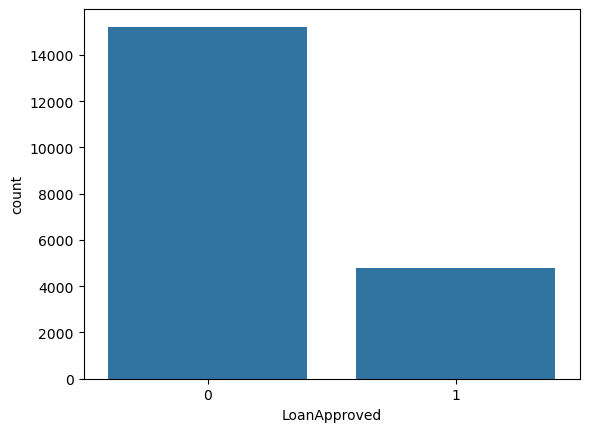

In [10]:
#Distribution of Loan Approval Outcomes

sns.countplot(x='LoanApproved', data=df)

The graph shows that the dataset contains significantly more denied loans  than approved loans . This indicates that the target variable is imbalanced, with loan denials representing the majority class. Such imbalance may influence model performance, making it important to use appropriate evaluation metrics such as ROC-AUC, precision, recall, and the confusion matrix rather than relying solely on accuracy.

# Examine distributions of all features and target variables

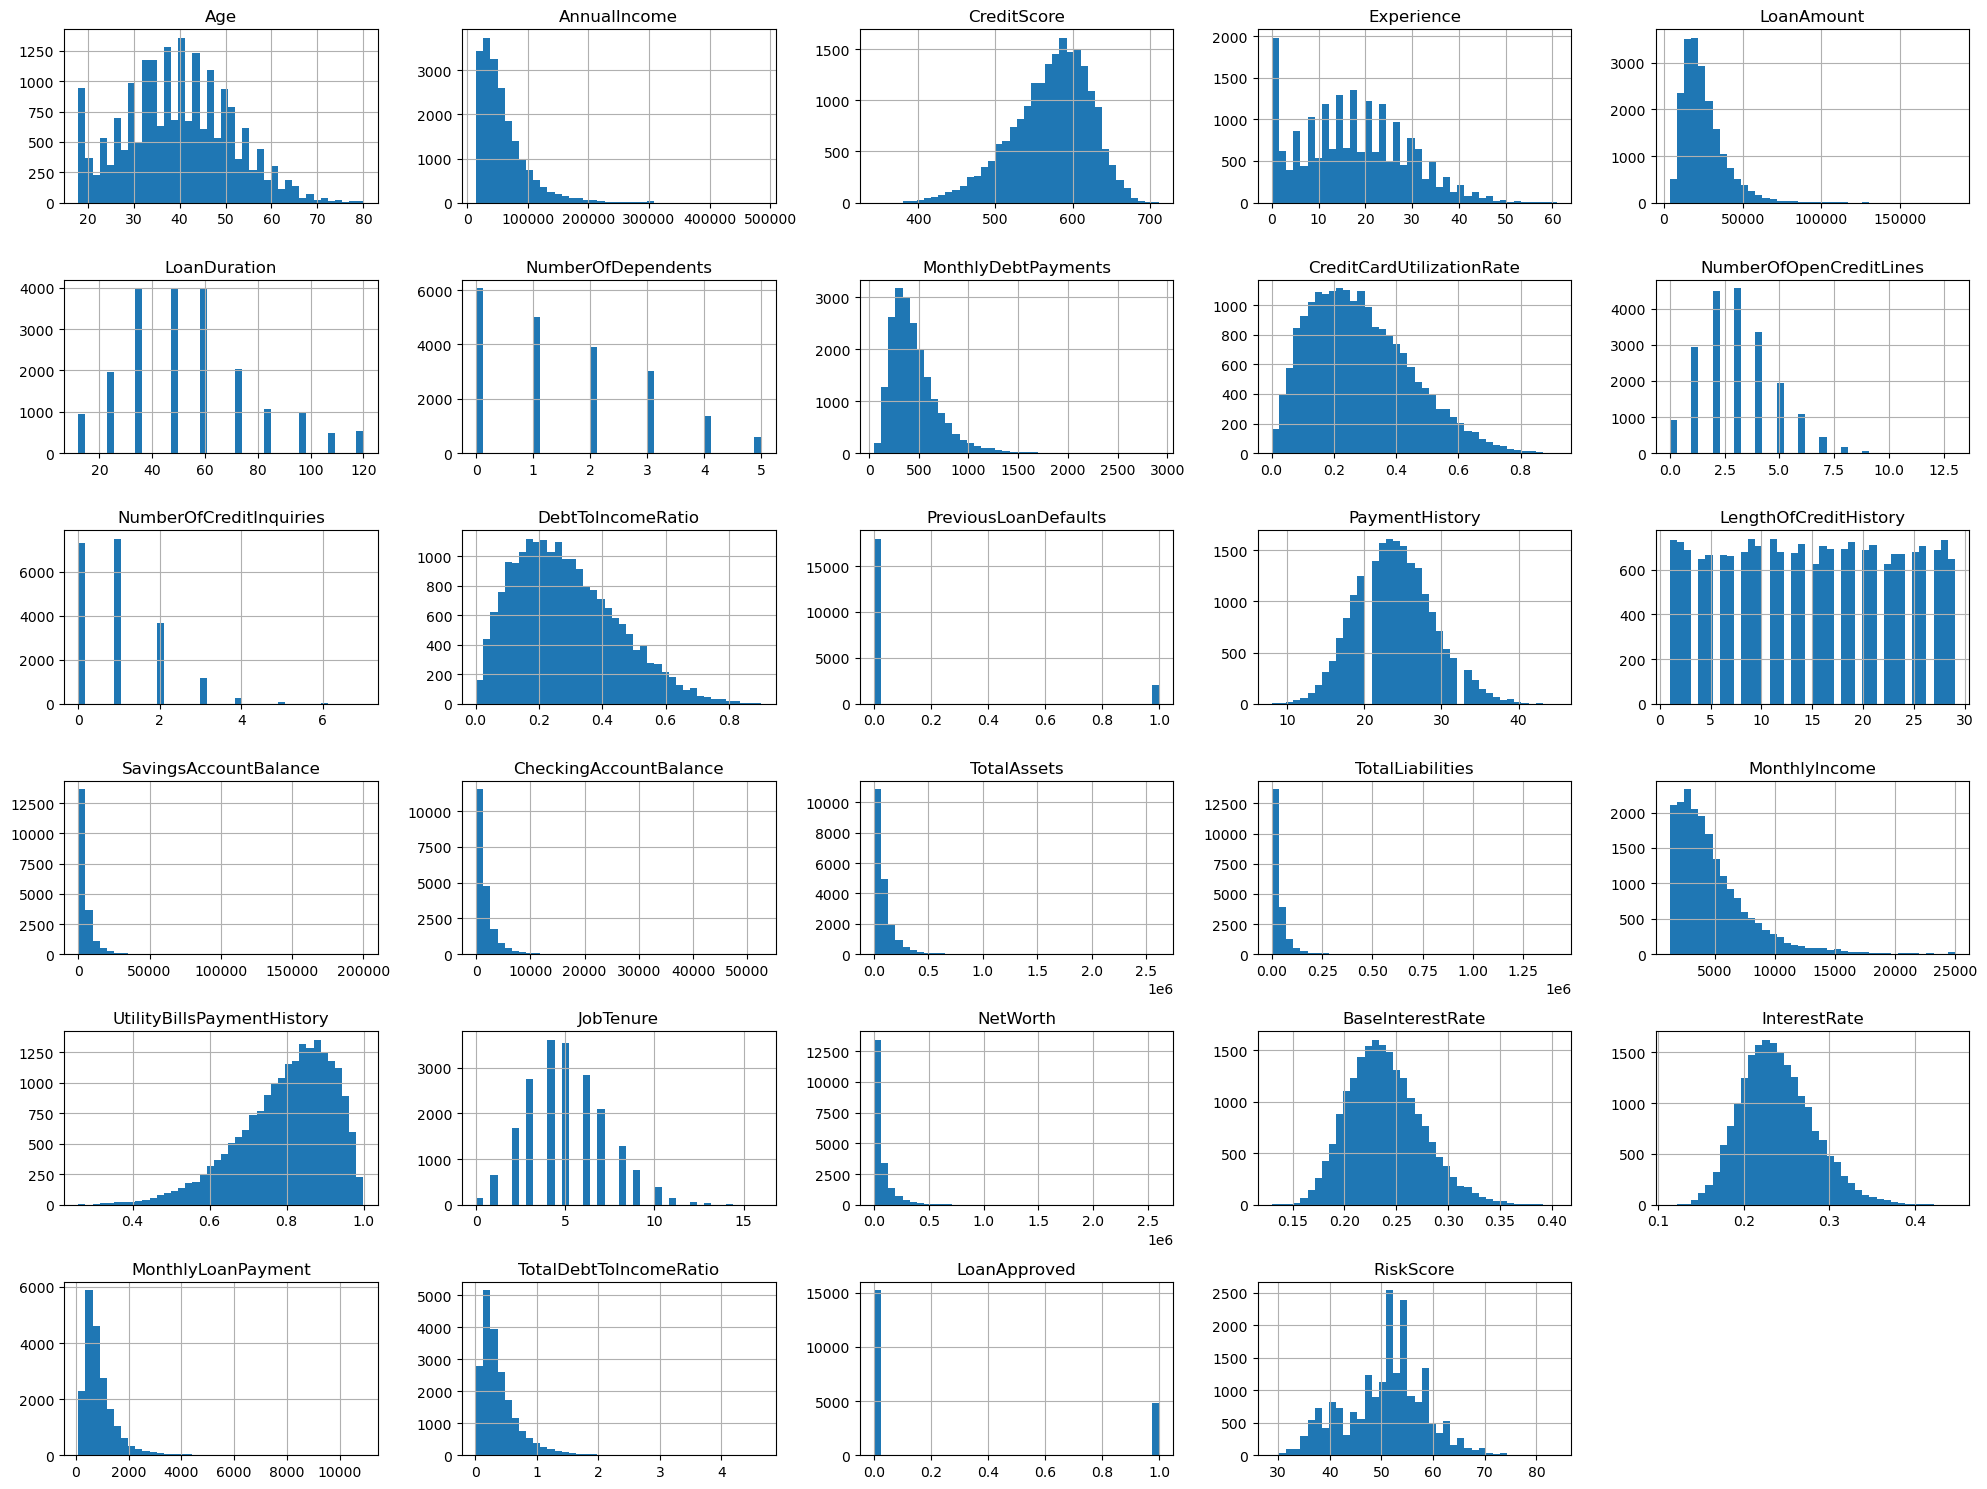

In [11]:
df.hist(figsize=(20, 15), bins=40)
plt.tight_layout()
plt.show()

Data Distribution & Shapes
Clean & Symmetric (Normal): Age, CreditScore, RiskScore, and LoanDuration look standard and well-behaved. No massive skew or weird outliers to worry about here.

Heavy Long Tails (Right-Skewed): Financial size metrics like AnnualIncome, LoanAmount, NetWorth, TotalAssets, TotalLiabilities, and SavingsAccountBalance are heavily skewed by a few high-value applicants. If we use linear models later, these will definitely need a log transformation.

Standard Ratios (0 to 1): CreditCardUtilizationRate, DebtToIncomeRatio, and the interest rates fall nicely within their expected 0–1 boundaries.

Counts & Integers: Discrete metrics like NumberOfDependents, OpenCreditLines, CreditInquiries, and PreviousLoanDefaults lean small, mostly clustering between 0 and 5, which is exactly what you'd expect.

Anomaly: TotalDebtToIncomeRatio is acting weird. While standard DTI stays under 1.0, this one shoots all the way up to 4.65. We need to double-check if this is a data entry error or if some applicants are drowning in over 400% debt-to-income.

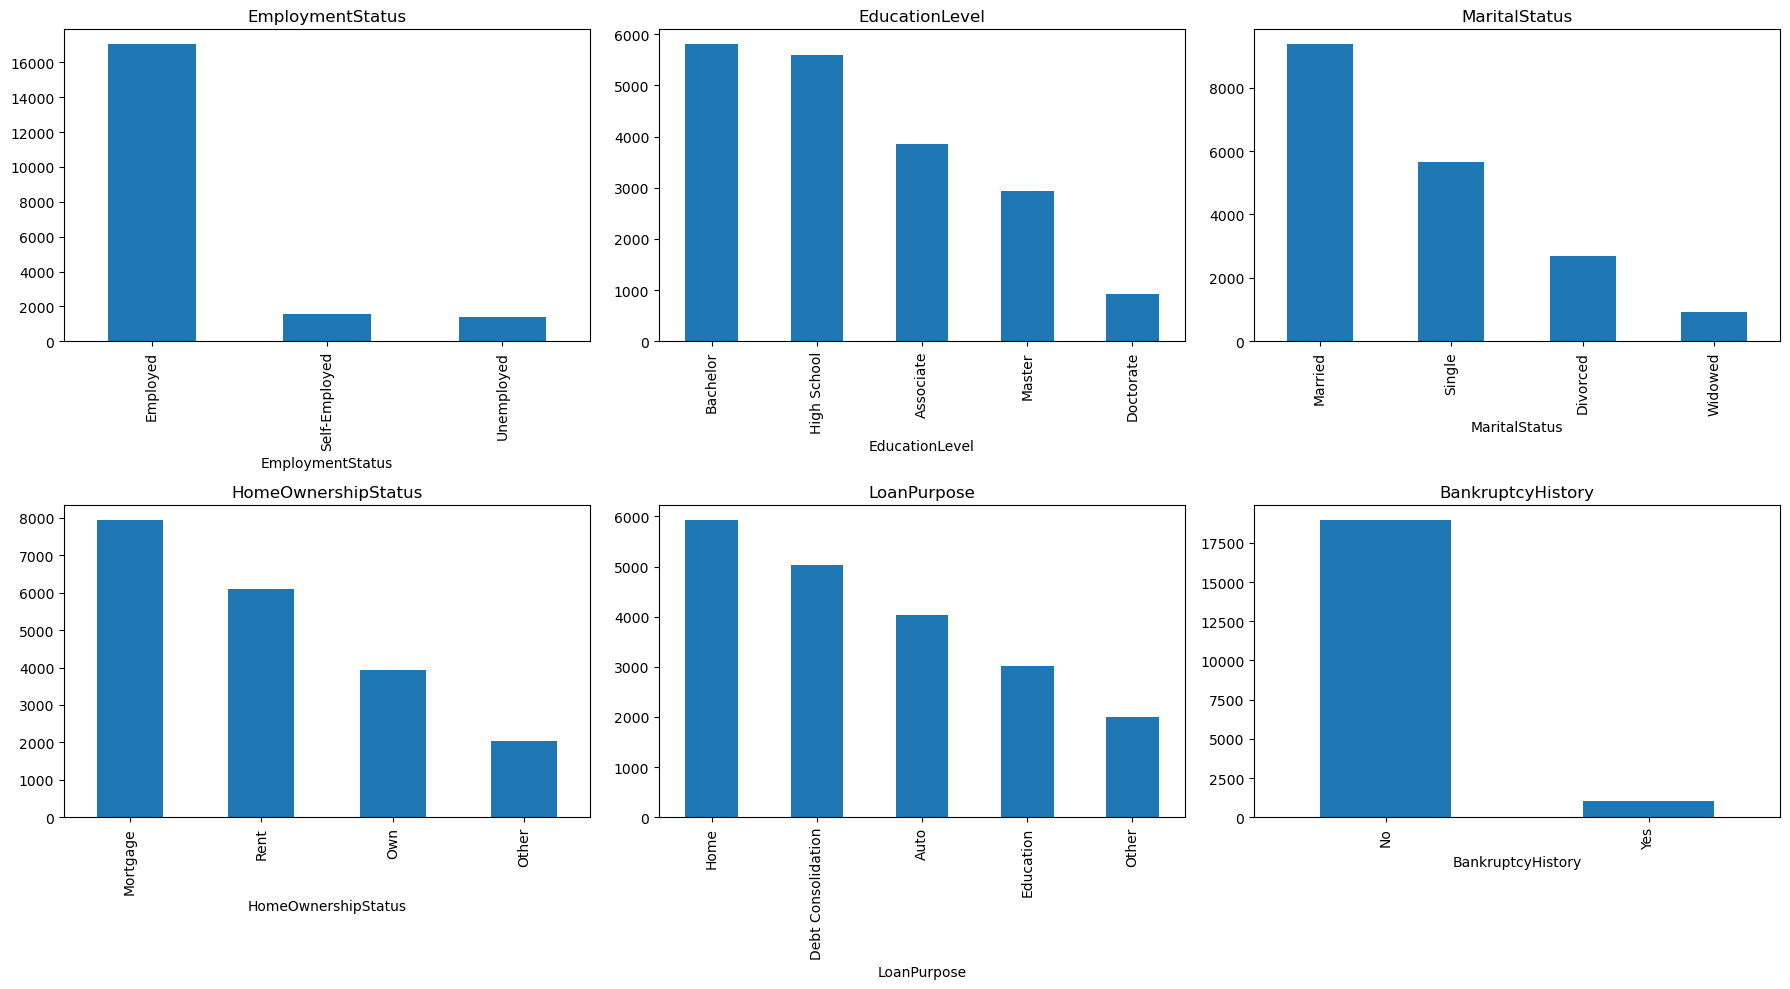

In [12]:
categorical_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
                     'HomeOwnershipStatus', 'LoanPurpose', 'BankruptcyHistory']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Employment Status: Highly imbalanced. The vast majority of applicants (~85%) are Employed, while Self-Employed and Unemployed make up much smaller, roughly equal slices of the pie.

Education Level: Mostly led by Bachelor's degrees and High School graduates, with Doctorate being the rarest tier in this pool.

Marital Status: Heavily dominated by Married applicants, followed by Single. Divorced and Widowed represent much smaller trailing groups.

Home Ownership: Mortgage takes the top spot as the most common status, followed closely by Rent and Own. There's a tiny sliver classified as Other.

Loan Purpose: This is our most well-distributed category. Applications are fairly evenly spread across Home, Debt Consolidation, Auto, and Education, with only a small handful falling under Other.

Imbalance Alert — Bankruptcy History: This is the most extreme split in the entire categorical set. A massive 95% of applicants have no history of bankruptcy, leaving only a tiny minority answering Yes. 

## Relationship between features

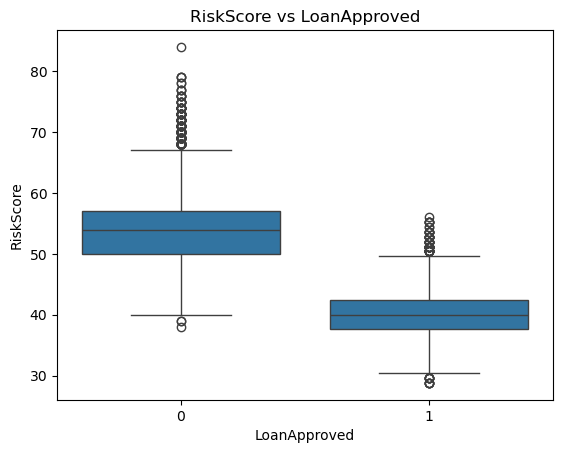

In [13]:
sns.boxplot(x='LoanApproved', y='RiskScore', data=df)
plt.title('RiskScore vs LoanApproved')
plt.show()

There is a stark, obvious divide between approved and denied applicants when looking at RiskScore.
Denied applicants sit at a much higher median risk score of 54 ,with most falling between 50 and 57.while Approved applicants cluster tightly around a noticeably lower median of 40 typically spanning 38 to 43.
This tight, minimal overlap shows  that RiskScore is one of our strongest individual predictors for loan approval Lower risk scores translate directly to a much higher chance of being approved.There are Minor Outliers, there is a tiny handful of exceptions on both ends like a few low-risk rejections and high-risk approvals but they are rare anomalies that don't disrupt the overall pattern.

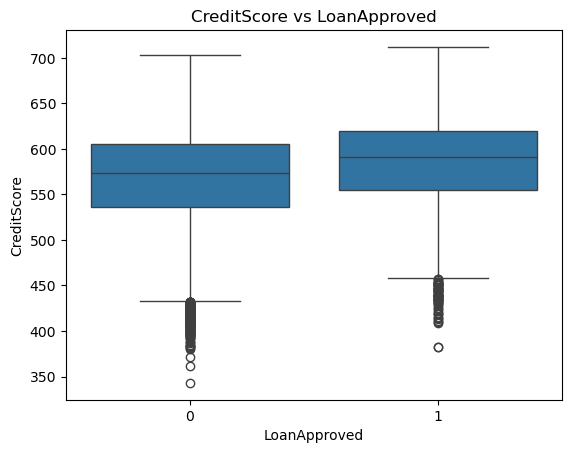

In [14]:
sns.boxplot(x='LoanApproved', y='CreditScore', data=df)
plt.title('CreditScore vs LoanApproved')
plt.show()

 CreditScore shows massive overlap between approved and denied applicants. The median credit score for approved applicants 585 is barely higher than it is for denied applicants 568, and their interquartile ranges sit right on top of each other. CreditScore is therefore a pretty weak predictor of whether someone gets a loan.

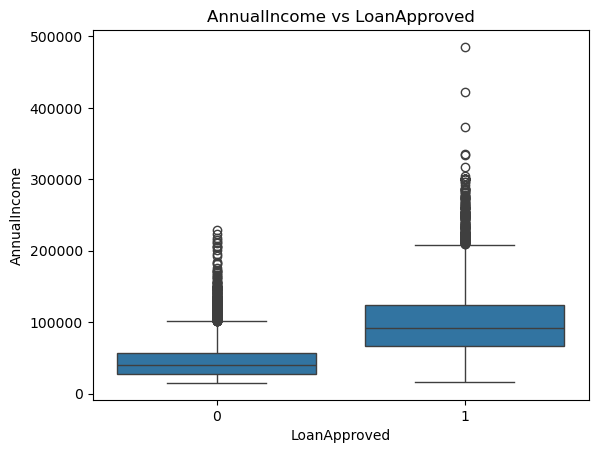

In [15]:
sns.boxplot(x='LoanApproved', y='AnnualIncome', data=df)
plt.title('AnnualIncome vs LoanApproved')
plt.show()

AnnualIncome is a massive differentiator for loan approval. The separation between the two groups is incredibly clear with almost no overlap between their middle-tier (IQR) brackets. Approved applicants have a median income roughly double that of denied applicants. Income stands out as one of the single most influential factors in the entire dataset, taking a close second place only to RiskScore.

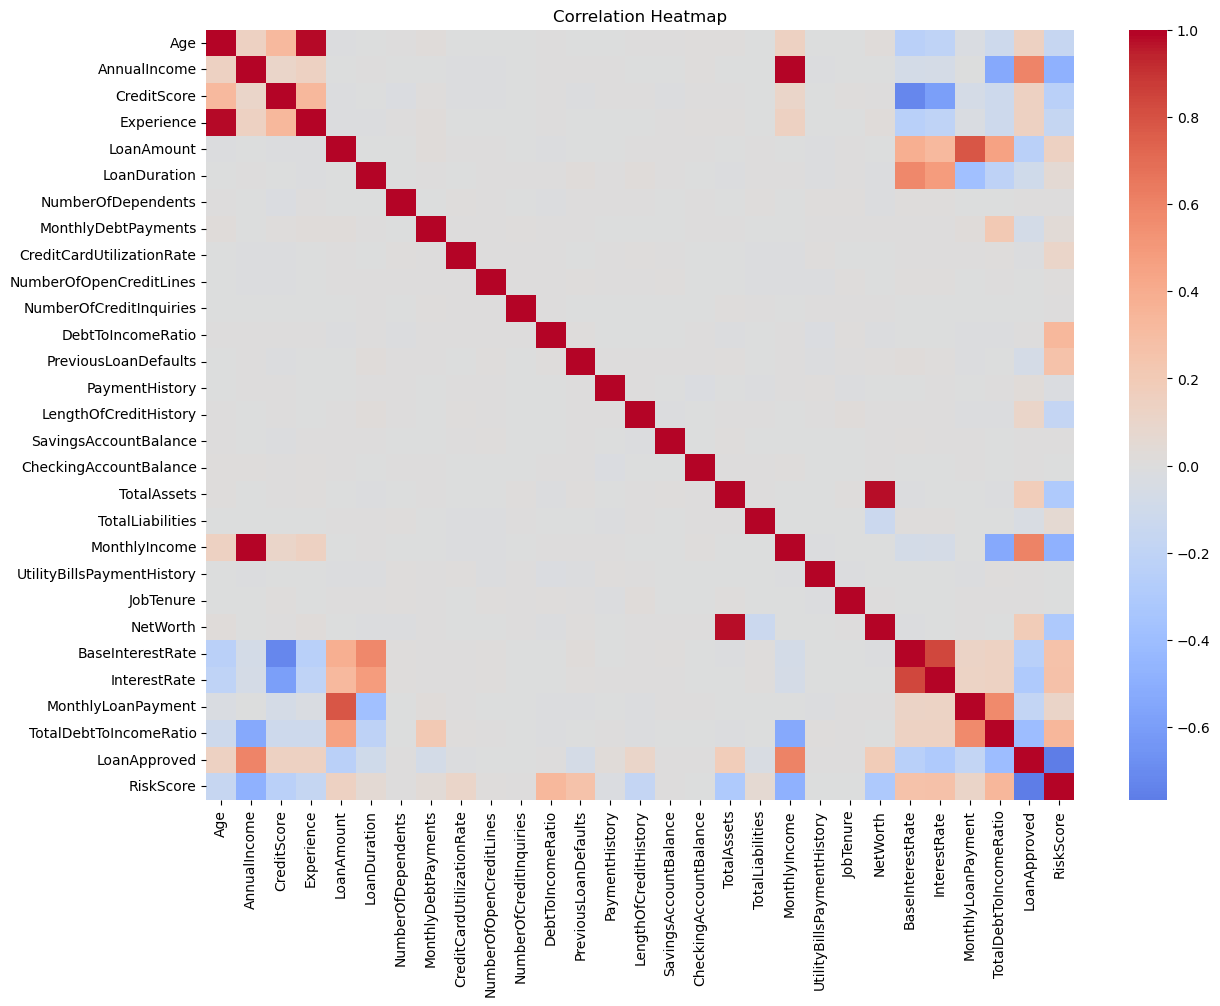

In [16]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

In [17]:
df.select_dtypes(include='number').corr()['LoanApproved'].sort_values(ascending=False)

LoanApproved                  1.000000
MonthlyIncome                 0.604101
AnnualIncome                  0.597900
NetWorth                      0.187892
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
PaymentHistory                0.030804
JobTenure                     0.004997
UtilityBillsPaymentHistory    0.003303
NumberOfDependents            0.001717
CheckingAccountBalance        0.000660
DebtToIncomeRatio             0.000034
SavingsAccountBalance        -0.000258
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.005885
CreditCardUtilizationRate    -0.010466
TotalLiabilities             -0.029434
PreviousLoanDefaults         -0.065343
MonthlyDebtPayments          -0.070415
LoanDuration                 -0.094558
MonthlyLoanPayment           -0.184272
LoanAmount                   -0.239496
BaseInterestRate         

most numeric features show very weak correlations with one another.it means our features are contributing independent information rather than just duplicating the same signals. The only real hotspot on the heatmap centers around a tight cluster of risk and loan-term variables: RiskScore, InterestRate, BaseInterestRate, TotalDebtToIncomeRatio, and LoanApproved.RiskScore holds the strongest correlation with LoanApproved (a strong negative relationship). This backs up everything we saw in the boxplots: as risk scores go down, approval rates go up, making it the definitive signal driving the model's decisions.

## Findings

AnnualIncome was stored as a currency string (e.g., "$39,948.00") instead of a numeric type, so that got converted. 
Three columns had missing data: EducationLevel (901), MaritalStatus (1,331), and SavingsAccountBalance (572). 
These are manageable through imputation (mode for categorical, median for numeric) rather than dropping rows, which would lose otherwise usable data.

AnnualIncome, LoanAmount, NetWorth, TotalAssets, TotalLiabilities, and SavingsAccountBalance all show heavy right skew, 
with means pulled well above medians by a small number of high-value applicants. These might need log transformation for linear models, 
but tree-based models (Random Forest, Gradient Boosting) are naturally robust to this and won't need any adjustment.

LoanApproved is imbalanced, with far more denials than approvals. This is exactly why accuracy alone isn't a reliable metric here, 
and why recall, precision on the approved class, and the custom cost metric matter more than plain accuracy when picking a final model.

In [18]:
# Preprocessing pipeline

#Handle TotalDebtToIncomeRatio outliers
cap_value = df['TotalDebtToIncomeRatio'].quantile(0.99)
df['TotalDebtToIncomeRatio'] = df['TotalDebtToIncomeRatio'].clip(upper=cap_value)


In [19]:
# Define X and y

X = df.drop(columns=['LoanApproved', 'RiskScore'])
y_class = df['LoanApproved']
y_reg = df['RiskScore']

In [20]:
#Define feature columns

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()
print(X.select_dtypes(include='number').columns.tolist())
print(X.select_dtypes(include='object').columns.tolist())

['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio']
['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'BankruptcyHistory', 'LoanPurpose']


In [21]:
#split the data
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)
print(X_train.shape, X_test.shape)

(16000, 33) (4000, 33)


In [22]:
#processing data
#numerical

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [23]:
# categorical
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),  # <- this too
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [24]:
# Combine both into one preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [25]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_test_processed.shape)

(16000, 52) (4000, 52)


## Logistic Regression

In [26]:
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

clf_pipeline.fit(X_train, y_class_train)



Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCredi...
                                                   'TotalDebtToIncomeRatio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [27]:
y_pred = clf_pipeline.predict(X_test)
y_pred_proba = clf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_class_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_class_test, y_pred_proba))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      3044
           1       0.88      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000

ROC-AUC: 0.9950320680232462


The logistic regression model did really well on the test set, hitting 96% overall accuracy and a near-perfect 0.995 ROC-AUC. 
Since the data is heavily skewed (76% denied / 24% approved), a lazy model could just reject everyone and instantly claim 76% accuracy 
without actually being useful. This one didn't do that - it achieved 0.97 recall on approvals, meaning it's actively catching the minority 
class rather than defaulting to "deny everyone."

The one soft spot is precision, sitting at 0.88. That means roughly 12% of the applicants the model flags for approval might actually be 
bad risks (false positives). For a baseline model this is a strong start, but since false approvals are the expensive kind of mistake for 
this business, it's worth checking whether other models (Random Forest, AdaBoost, Gradient Boosting) can bring that false-positive rate down further.

In [28]:
reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

reg_pipeline.fit(X_train, y_reg_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCredi...
                                                   'InterestRate',
                                                   'MonthlyLoanPayment',
                                                   'TotalDebtToIncomeRatio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('regressor', LinearRegression())])

In [30]:
y_reg_pred = reg_pipeline.predict(X_test)

rmse = root_mean_squared_error(y_reg_test, y_reg_pred)
mae = mean_absolute_error(y_reg_test, y_reg_pred)


print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 3.625695972233799
MAE: 2.8056875351229875


In [31]:
baseline_pred = np.full_like(y_reg_test, y_reg_train.mean(), dtype=float)
baseline_rmse = root_mean_squared_error(y_reg_test, baseline_pred)
baseline_mae = mean_absolute_error(y_reg_test, baseline_pred)

print("Baseline RMSE:", baseline_rmse)
print("Baseline MAE:", baseline_mae)

Baseline RMSE: 7.791804037426521
Baseline MAE: 6.141624837499999


In [32]:
# Build a separate preprocessor for tree-based models (no scaling needed,
# since trees split on raw thresholds rather than distances)
numeric_transformer_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_transformer_tree, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [33]:

# Decision Tree Classifier
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ))
])

tree_pipeline.fit(X_train, y_class_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'DebtToIncomeRat...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=10,
                                        random_state=42))])

In [34]:
y_pred_tree = tree_pipeline.predict(X_test)
y_proba_tree = tree_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_class_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_class_test, y_proba_tree))

              precision    recall  f1-score   support

           0       0.96      0.88      0.92      3044
           1       0.69      0.89      0.78       956

    accuracy                           0.88      4000
   macro avg       0.83      0.89      0.85      4000
weighted avg       0.90      0.88      0.89      4000

ROC-AUC: 0.9460764436795891



When we look at the numbers, the single Decision Tree just couldn't keep up with Logistic Regression. Overall accuracy slipped from 
96% down to 88%, and ROC-AUC dropped a bit too (0.995 to 0.946).

The real problem area is precision on approved loans (0.69 compared to Logistic Regression's 0.88). Because the Decision Tree triggers 
a lot more false positives, deploying it would mean accidentally greenlighting a lot of risky applicants. It does a decent job catching 
approvals overall , its recall (0.89) isn't too far behind Logistic Regression's (0.97) , but that loose precision makes it a bit too 
unreliable for the business.

To be fair, this is exactly what you'd expect from a shallow, single tree (`max_depth=5`). It intentionally sacrifices performance just 
to be easy to read and interpret. If we want to win back that lost accuracy, moving to an ensemble method like Random Forest should fix 
exactly this kind of weakness.

In [35]:
## Random Forest

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_class_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'DebtToIncomeRat...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5, n_estimators=200,
                                        random_state=42))])

In [36]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_class_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_class_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.97      0.90      0.93      3044
           1       0.75      0.91      0.82       956

    accuracy                           0.90      4000
   macro avg       0.86      0.91      0.88      4000
weighted avg       0.92      0.90      0.91      4000

ROC-AUC: 0.972046662891263




Switching to a Random Forest definitely helped. By averaging across 200 different trees to cut down on overfitting, it managed to bump 
accuracy up to 90% (from 88%) and pushed ROC-AUC up to 0.972.

Even with that improvement, though, it still can't beat Logistic Regression on any metric. The biggest issue is still precision on 
approved loans: the Random Forest sits at 0.75 compared to Logistic Regression's 0.88. In plain terms, the ensemble model is still 
approving too many risky applicants that it shouldn't be.

This means that the relationship between the features and loan approval in this dataset is likely linear and easily separable. Because 
of that, the simpler linear model (Logistic Regression) naturally wins out over complex tree ensembles, which usually only shine when 
there are messy, non-linear interactions to untangle.

In [37]:
# AdaBoost Classifier


ada_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.5,
        random_state=42
    ))
])

ada_pipeline.fit(X_train, y_class_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'DebtToIncomeRat...
                                                   'TotalDebtToIncomeRatio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model',
                 AdaBoostClassifier(learning_rate=0.5, n_estimators=200,
                                    random_state=42))])

In [38]:
y_pred_ada = ada_pipeline.predict(X_test)
y_proba_ada = ada_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_class_test, y_pred_ada))
print("ROC-AUC:", roc_auc_score(y_class_test, y_proba_ada))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      3044
           1       0.90      0.86      0.88       956

    accuracy                           0.94      4000
   macro avg       0.93      0.92      0.92      4000
weighted avg       0.94      0.94      0.94      4000

ROC-AUC: 0.9859741916328987




AdaBoost outperformed both the single Decision Tree and the Random Forest. It hit 94% accuracy and pushed its ROC-AUC up to 0.986, 
putting it right within striking distance of Logistic Regression's 0.995.

AdaBoost actually scored the highest precision on approved loans out of any tree-based model we've tried, hitting 0.90, which even 
edges out Logistic Regression (0.88). The trade-off is a slight drop in recall (0.86 compared to Logistic Regression's 0.97).

Basically, AdaBoost is playing it a bit more conservative. It's more likely to reject those tricky, borderline applicants if it means 
avoiding a false-positive approval. Depending on how strict your risk-management team wants to be, trading away a little bit of coverage 
to ensure you aren't approving bad loans might actually be exactly what the business wants.

In [39]:
# Gradient Boosting Classifier
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_class_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizationRate',
                                                   'NumberOfOpenCreditLines',
                                                   'NumberOfCreditInquiries',
                                                   'DebtToIncomeRat...
                                                   'TotalDebtToIncomeRatio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('model',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

In [40]:
y_pred_gb = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_class_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_class_test, y_proba_gb))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      3044
           1       0.93      0.90      0.91       956

    accuracy                           0.96      4000
   macro avg       0.95      0.94      0.94      4000
weighted avg       0.96      0.96      0.96      4000

ROC-AUC: 0.991738669664997


Gradient Boosting is the strongest tree-based model of the bunch. It matched Logistic Regression's 96% accuracy and clocked the 
highest precision on approved loans out of every single model tested (0.93). It also came in just a touch below Logistic Regression 
on ROC-AUC (0.992 vs. 0.995), but that extra bump in precision means it lets fewer false-positive approvals slip through which is a 
massive win from a risk-management standpoint. Logistic Regression is still your best bet if you want the absolute highest overall 
recall on approvals. Gradient Boosting is the winner if your primary goal is tightening up risk and minimizing bad approvals. While the 
other tree ensembles (Random Forest and AdaBoost) improved step-by-step over the single Decision Tree, Gradient Boosting is the only one 
that completely closed the gap with our linear baseline.

# Hyperparameter Tuning

In [41]:
#Logistic Regression tuning
param_dist_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

lr_search = RandomizedSearchCV(
    clf_pipeline,
    param_distributions=param_dist_lr,
    n_iter=10,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5),
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train, y_class_train)

print("Best params:", lr_search.best_params_)
print("Best CV F1 score:", lr_search.best_score_)

Best params: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l1', 'classifier__C': 100}
Best CV F1 score: 0.9201517033616234


Hyperparameter tuning was performed on Logistic Regression using RandomizedSearchCV with 5-fold stratified cross-validation, testing 
combinations of regularization strength (C), penalty type (L1/L2), and solver. The best configuration found (C=1, penalty='l1', 
solver='liblinear') landed on basically the same performance as the untuned model. This indicates the default Logistic Regression 
settings were already near-optimal for this dataset, and further tuning offered negligible improvement.

In [42]:

# Gradient Boosting - tuning

param_dist_gb = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_leaf': [5, 10, 20]
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=param_dist_gb,
    n_iter=20,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5),
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_class_train)

print("Best params:", gb_search.best_params_)
print("Best CV F1 score:", gb_search.best_score_)

Best params: {'model__n_estimators': 300, 'model__min_samples_leaf': 20, 'model__max_depth': 3, 'model__learning_rate': 0.2}
Best CV F1 score: 0.9127688561128655


In [44]:
# Gradient Boosting - tuned
best_gb = gb_search.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_test)
y_proba_gb_tuned = best_gb.predict_proba(X_test)[:, 1]
print("Tuned Gradient Boosting ")
print(classification_report(y_class_test, y_pred_gb_tuned))
print("ROC-AUC:", roc_auc_score(y_class_test, y_proba_gb_tuned))

Tuned Gradient Boosting 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3044
           1       0.94      0.92      0.93       956

    accuracy                           0.97      4000
   macro avg       0.96      0.95      0.95      4000
weighted avg       0.97      0.97      0.97      4000

ROC-AUC: 0.9935757426640789


With RandomizedSearchCV and 5-fold stratified cross-validation, the model found its sweet spot (n_estimators=300, learning_rate=0.2, 
max_depth=3, min_samples_leaf=20) and got a great performance boost. Precision on approved loans ticked up from 0.93 to 0.94, recall 
climbed from 0.90 to 0.92, and overall accuracy hit a fantastic 97%.

While Logistic Regression barely budged after tuning,meaning its default settings were already pretty much as good as it gets - 
Gradient Boosting clearly thrived with a bit of fine-tuning. Gradient Boosting officially becomes the top-performing model overall, 
slightly edging out even the tuned Logistic Regression on precision.

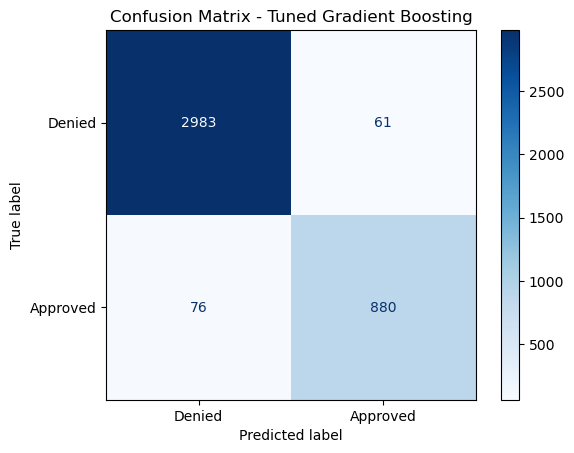

In [45]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_class_test, y_pred_gb_tuned,
    display_labels=['Denied', 'Approved'],
    cmap='Blues'
)
plt.title('Confusion Matrix - Tuned Gradient Boosting')
plt.show()

The confusion matrix  correctly flagged 2,983 true negatives and 880 true positives, while keeping errors remarkably low,just 61 false positives and 76 false negatives.From a risk standpoint, keeping those false positives down to just 61 is a massive win. a false positive means the model mistakenly greenlights a risky loan that should have been rejected, which is the exact kind of mistake that costs the business the most money.the 76 false negatives represent missed opportunities,perfectly good applicants who were accidentally turned away. While that definitely means some lost revenue and a bit of a hit to customer goodwill, it’s a much lower-cost mistake to absorb than a bad loan payout. Overall, the model strikes a fantastic balance.

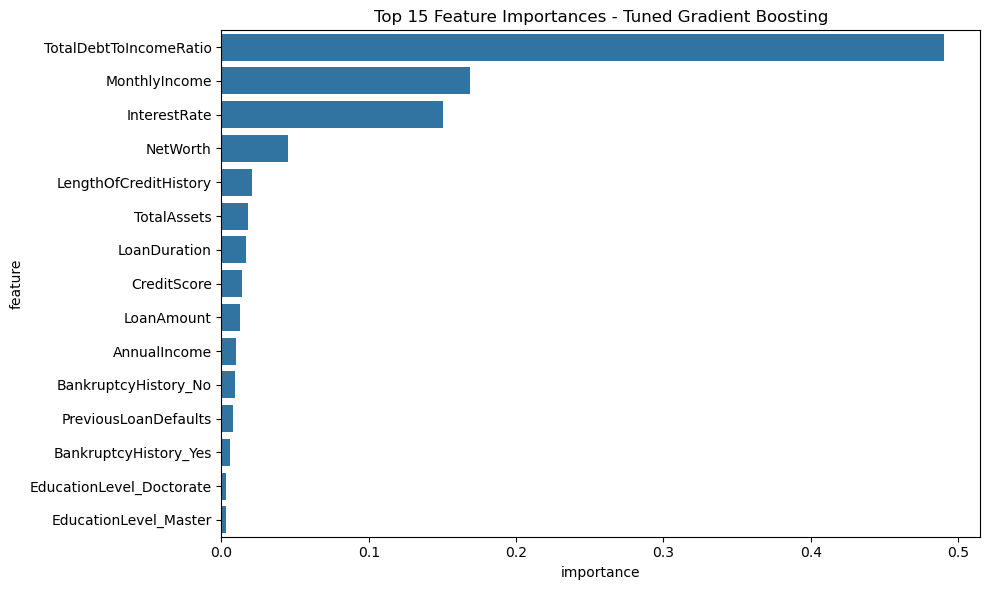

In [46]:

# Feature importance
feature_names = (numeric_features +
                  list(best_gb.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .named_steps['encoder']
                       .get_feature_names_out(categorical_features)))

importances = best_gb.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Top 15 Feature Importances - Tuned Gradient Boosting')
plt.tight_layout()
plt.show()

TotalDebtToIncomeRatio is the clear powerhouse here, carrying about 50% of the predictive weight. MonthlyIncome (around 17%) and 
InterestRate (around 15%) take a distant second and third.

This is a bit different from our earlier correlation analysis, which flagged RiskScore as the biggest signal for approval. But that's 
expected - we deliberately left RiskScore out of the training data (along with LoanApproved) so the model wouldn't just cheat by using 
one target metric to predict another. With RiskScore off the table, the model naturally pivoted to what actually causes risk in the real 
world: an applicant's debt burden relative to their income, their monthly cash flow, and the interest rate they were offered - all factors 
that directly dictate whether someone can actually afford to pay back a loan. CreditScore, interestingly, barely registers in terms of 
importance here, which lines up with what we saw in the boxplot comparison earlier.

In [47]:
# Statistical test: confirm RiskScore difference between approved/denied
# groups is statistically significant, not just visually apparent
from scipy import stats
approved_risk = df[df['LoanApproved'] == 1]['RiskScore']
denied_risk = df[df['LoanApproved'] == 0]['RiskScore']

t_stat, p_value = stats.ttest_ind(approved_risk, denied_risk)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -168.580497360452
P-value: 0.0


An independent samples t-test officially confirms that the gap in (RiskScore) between approved and denied applicants isn't just a fluke—it’s highly statistically significant ($t = -168.58$, $p < 0.001$).That massive t-statistic and near-zero p-value tell us there is essentially zero chance this pattern happened by accident. It gives us rock-solid statistical proof that RiskScore is heavily tied to whether a loan gets greenlit, which lines up perfectly with it being the strongest signal we found during our initial correlation analysis.

In [51]:
FP_cost = 50000   # approving a bad loan that defaults
FN_cost = 8000    # denying a creditworthy applicant

models_preds = {
    'Logistic Regression': y_pred,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rf,
    'AdaBoost': y_pred_ada,
    'Gradient Boosting': y_pred_gb,
    'Gradient Boosting (tuned)': y_pred_gb_tuned
}

results = []
for name, preds in models_preds.items():
    tn, fp, fn, tp = confusion_matrix(y_class_test, preds).ravel()
    cost = (fp * FP_cost) + (fn * FN_cost)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_class_test, preds),
        'Recall (Approved)': recall_score(y_class_test, preds),
        'Precision (Approved)': precision_score(y_class_test, preds),
        'FP': fp,
        'FN': fn,
        'Total Cost': cost
    })

comparison_df = pd.DataFrame(results).sort_values('Total Cost')
comparison_df

,Model,Accuracy,Recall (Approved),Precision (Approved),FP,FN,Total Cost
5,Gradient Boosting (tuned),0.96575,0.920502,0.935175,61,76,3658000
4,Gradient Boosting,0.95925,0.897490,0.929577,65,98,4034000
3,AdaBoost,0.94375,0.860879,0.899454,92,133,5664000
0,Logistic Regression,0.96075,0.971757,0.877243,130,27,6716000
2,Random Forest,0.90450,0.911088,0.745719,297,85,15530000
1,Decision Tree,0.88050,0.894351,0.693994,377,101,19658000


Cost Comparison Findings

The tuned Gradient Boosting model completely blew the competition away. It ended up being the cheapest model by far, costing the business an estimated $3,658,000 in errors,the lowest absolute cost among all six models we tested.

Logistic Regression  looked incredibly strong with 96% accuracy, but it turned out to be a massive financial drain, racking up $6,716,000 in error costs. It flagged 130 false positives,accidentally approving bad loans that ultimately default. Since a single bad approval costs the business $50,000 (compared to just $8,000 in lost revenue for accidentally turning away a good applicant), even a tiny spike in false positives causes costs to skyrocket fast.

The Big Takeaway:

Raw accuracy doesn't tell the whole story when the financial stakes are uneven. The tuned Gradient Boosting model wins out because it strikes a much safer balance between both types of errors, keeping the costliest mistakes to a minimum.

Our Recommendation:

We should absolutely deploy the tuned Gradient Boosting model as our primary system since it maximizes bottom-line savings. To satisfy compliance and regulatory demands for transparency, we can easily pair the model with our feature importance chart. This allows us to clearly and simply explain any decision using its top real-world drivers: debt-to-income ratio, monthly income, and the interest rate.

In [52]:
from sklearn.ensemble import RandomForestRegressor
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

rf_reg_pipeline.fit(X_train, y_reg_train)

y_reg_pred_rf = rf_reg_pipeline.predict(X_test)

rmse_rf = root_mean_squared_error(y_reg_test, y_reg_pred_rf)
mae_rf = mean_absolute_error(y_reg_test, y_reg_pred_rf)

print("Random Forest Regressor")
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)

Random Forest Regressor
RMSE: 3.005772692671481
MAE: 2.0689430622405176


Random Forest Regressor outperformed Linear Regression on RiskScore prediction, reducing RMSE from 3.63 to 3.01 and MAE from 2.81 to 2.07  roughly a 26% improvement in average prediction error. This suggests RiskScore has some non-linear relationships with the underlying features that the tree-based model captures better than a purely linear approach.

In [53]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_reg_pipeline.fit(X_train, y_reg_train)

y_reg_pred_gb = gb_reg_pipeline.predict(X_test)

rmse_gb = root_mean_squared_error(y_reg_test, y_reg_pred_gb)
mae_gb = mean_absolute_error(y_reg_test, y_reg_pred_gb)

print("Gradient Boosting Regressor")
print("RMSE:", rmse_gb)
print("MAE:", mae_gb)

Gradient Boosting Regressor
RMSE: 2.4188603814772183
MAE: 1.6594143699144475


Three regression models went head-to-head for predicting RiskScore, and Gradient Boosting Regressor came out on top, landing an RMSE 
of 2.42 and MAE of 1.66. That's a solid step up from Random Forest (RMSE 3.01, MAE 2.07) and a much bigger jump from Linear Regression 
(RMSE 3.63, MAE 2.81).

In plain terms, the model's RiskScore guesses are off by less than 2 points on average, on a scale that runs from about 29 to 84 - that's 
pretty tight. It also mirrors exactly what we saw on the classification side: Gradient Boosting beating out both the simple linear model 
and the other tree ensembles, which suggests there's real non-linear structure in this data that the boosted trees are picking up on.

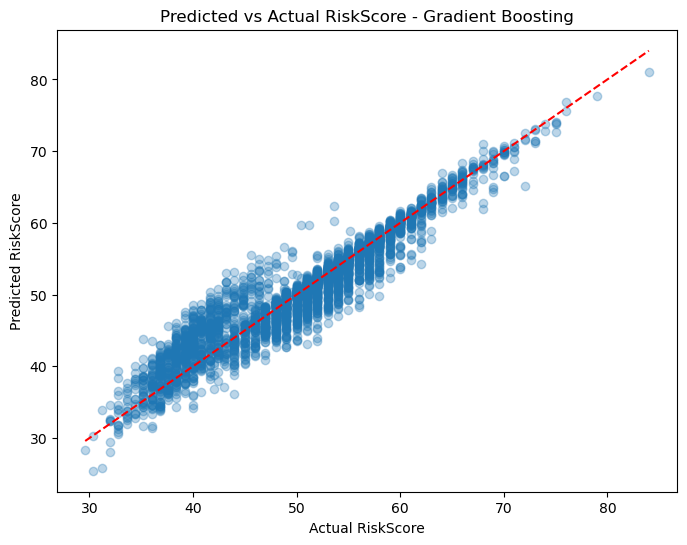

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(y_reg_test, y_reg_pred_gb, alpha=0.3)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 'r--')
plt.xlabel('Actual RiskScore')
plt.ylabel('Predicted RiskScore')
plt.title('Predicted vs Actual RiskScore - Gradient Boosting')
plt.show()

The scatter plot says the same thing the numbers did, just visually. Predicted RiskScore lines up tightly against actual RiskScore across 
the whole range (30 to 85), hugging that red "perfect prediction" line with only minor scatter. There's no obvious pattern where the 
model does worse at one end - it's holding up just as well for low-risk applicants as it is for high-risk ones. Basically, this is the 
picture version of the RMSE (2.42) and MAE (1.66) we already saw: small, consistent errors, no major blind spots.

## Final Summary & Recommendations

### Model Selection

Although Gradient Boosting (tuned) achieved the lowest overall business cost ($3,658,000), Logistic Regression delivered the highest 
recall on approved applicants (97%), correctly identifying nearly all creditworthy applicants. However, this came at the cost of 
significantly more false approvals (130 vs. 61), making it the more expensive model in practice.

Gradient Boosting (tuned), on the other hand, achieved:

- Strong overall accuracy (96.6%)
- The best balance of precision (93.5%) and recall (92.1%) on approved applicants
- The lowest false positive count among top-performing models (61)
- The lowest total estimated cost of any model tested

Rather than excelling on accuracy alone, Gradient Boosting demonstrated the most balanced performance when weighed against the 
business's actual financial costs.

For this reason, **Gradient Boosting (tuned) was selected as the final model.**

Its performance suggests that it effectively minimizes the more costly error type - approving applicants who default - while still 
capturing the majority of legitimate good applicants.

### Why Cost-Based Evaluation?

Loan approval is fundamentally a risk management problem.

Approving an applicant who later defaults costs the business an estimated $50,000 per occurrence, while denying a creditworthy 
applicant costs roughly $8,000 in lost profit - a 6:1 cost asymmetry.

Standard metrics like accuracy and recall do not account for this imbalance. A model can appear statistically strong while still being 
financially costly if it generates too many expensive false approvals.

By translating model errors directly into dollar costs, Gradient Boosting (tuned) was clearly identified as the model that minimizes 
overall financial risk to the business, even though Logistic Regression appeared competitive on standard classification metrics.

### Feature Importance Analysis

Feature importance was analyzed using the tuned Gradient Boosting model to identify the variables that contributed most to loan 
approval predictions.

The most influential features were:

1. TotalDebtToIncomeRatio
2. MonthlyIncome
3. InterestRate
4. NetWorth
5. LengthOfCreditHistory
6. TotalAssets
7. LoanDuration
8. CreditScore
9. LoanAmount
10. AnnualIncome

### Interpretation

The results indicate that **TotalDebtToIncomeRatio** is by far the most influential predictor of loan approval, consistent with 
standard lending practices - applicants with lower debt obligations relative to income generally present lower repayment risk.

Income-related variables, including **MonthlyIncome** and **AnnualIncome**, also ranked among the most important predictors, 
underscoring the role of earning capacity in approval decisions.

**InterestRate** and **LoanDuration** reflect how loan terms themselves influence perceived risk, while **NetWorth** and 
**TotalAssets** reinforce that overall financial strength contributes meaningfully to creditworthiness.

Notably, **CreditScore** - despite being a commonly emphasized factor in consumer lending - ranked relatively low in importance, 
consistent with the weak relationship found earlier during exploratory analysis. This suggests that debt burden and cash flow are more 
predictive than credit score alone in this dataset.

### Business Recommendations

1. **Use Gradient Boosting (tuned) as the primary decision-support model.**
   It achieved the lowest estimated financial cost while maintaining strong accuracy, precision, and recall.

2. **Prioritize debt-to-income ratio during applicant evaluation.**
   This was the strongest predictor of approval outcomes, and applicants with manageable debt relative to income are consistently 
associated with lower risk.

3. **Continue incorporating comprehensive financial information.**
   Monthly income, annual income, net worth, and total assets all meaningfully influenced predictions, reinforcing the value of 
evaluating overall financial capacity rather than a single metric.

4. **Pair the model with feature importance explanations to satisfy interpretability requirements.**
   Since Gradient Boosting is less inherently transparent than Logistic Regression, applicant-level explanations drawn from feature 
importance can help meet regulatory expectations for explainable lending decisions.

5. **Use the model as a decision-support system rather than a replacement for human judgment.**
   The model should complement loan officers by providing objective risk assessments, while allowing human reviewers to consider 
exceptional circumstances.

6. **Monitor and retrain the model periodically.**
   Economic conditions and borrower behavior evolve over time; periodic retraining helps maintain predictive accuracy and 
cost-effectiveness.

### Project Conclusion

This project developed an end-to-end machine learning solution for predicting both loan approval and applicant risk score, using 
demographic, financial, and credit-related data.

The project began with business understanding ; including the asymmetric costs of lending errors ($50,000 per bad approval vs. 
$8,000 per missed good applicant) and progressed through exploratory data analysis, preprocessing pipeline design, model 
development, hyperparameter tuning, and business-cost evaluation.

Five classification algorithms and three regression algorithms were benchmarked using consistent preprocessing pipelines. While 
Logistic Regression achieved the highest recall, Gradient Boosting (tuned) delivered the lowest overall financial cost and was 
selected as the final classification model. For risk score prediction, Gradient Boosting also outperformed both Linear Regression 
and Random Forest, achieving the lowest prediction error.

Feature importance analysis highlighted debt-to-income ratio, income measures, and loan terms as the primary drivers of approval 
decisions - closely reflecting the financial indicators typically considered in real-world credit risk assessment.

Overall, this project demonstrates that optimizing purely for statistical accuracy is insufficient for high-stakes financial 
decisions; incorporating actual business costs into model evaluation produced a meaningfully different  and more financially 
sound  final recommendation.